# Instagram Engagement Prediction and Analysis Notebook
This notebook demonstrates a complete workflow for predicting and analyzing sentiment-weighted engagement on Instagram posts using machine learning and deep learning models. It includes data preprocessing, feature engineering, model training (XGBoost, LightGBM, DNN), evaluation, visualizations, SHAP explainability, and a keyword recommendation system.

In [1]:
!pip install transformers shap xgboost lightgbm nltk wordcloud -q

In [54]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
from sklearn.preprocessing import KBinsDiscretizer
import xgboost as xgb
import lightgbm as lgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import tensorflow as tf
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from google.colab import files
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)  # Added to fix LookupError

True

In [3]:
# Suppress Hugging Face token warning (optional)
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Verify transformers installation
try:
    from transformers import BertModel
    print("Transformers library loaded successfully.")
except ImportError:
    print("Error: Transformers library not properly installed. Please check installation.")
    raise

Transformers library loaded successfully.


## Upload your Instagram dataset
Please upload your Instagram dataset CSV file. The file should contain columns such as captions, hashtags, engagement metrics, and sentiment scores.

In [4]:
# Upload dataset
print("Please upload your Instagram dataset CSV file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
data = pd.read_csv(file_name)

Please upload your Instagram dataset CSV file:


Saving final_combined_dataset.csv to final_combined_dataset.csv


In [58]:

# Preprocessing: Handle missing values
data['caption'] = data['caption'].fillna('')
data['hashtags'] = data['hashtags'].fillna('')
data['comment_text'] = data['comment_text'].fillna('')
data = data.fillna(0)

# Clean hashtags column to ensure valid tokens
def clean_hashtags(text):
    if not isinstance(text, str):
        return ''
    text = ' '.join([word.strip() for word in text.split() if word.startswith('#') and len(word) > 1])
    return text  # Return empty string if no valid hashtags,

data['hashtags'] = data['hashtags'].apply(clean_hashtags)

# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')


In [59]:

# Define features to exclude (sentiment-related and target)
exclude_cols = [
    'sentiment', 'sentiment_confidence', 'sentiment_positive', 'sentiment_negative',
    'sentiment_neutral', 'sentiment_positive_post', 'sentiment_negative_post',
    'sentiment_neutral_post', 'avg_comment_sentiment', 'sentiment_weighted_engagement'
]

# Feature selection
features = [
    'likes', 'comments_count', 'caption', 'hashtags', 'media_type', 'is_private',
    'is_verified', 'caption_length', 'num_hashtags', 'has_mention', 'has_url',
    'follower_adjusted_likes', 'follower_adjusted_comments', 'engagement_rate',
    'engagement_frequency', 'influence_score', 'content_interaction',
    'comment_engagement_ratio', 'comment_length', 'has_emoji',
    'category_beauty', 'category_family', 'category_fashion', 'category_fitness',
    'category_food', 'category_pet', 'category_travel', '#Followers',
    '#Followees', '#Posts', 'num_comments', 'comment_likes_sum'
]

X = data[features]
y = data['sentiment_weighted_engagement']


In [60]:

# Encode categorical variables
le_media_type = LabelEncoder()
X['media_type'] = le_media_type.fit_transform(X['media_type'])


/tmp/ipython-input-60-247347918.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['media_type'] = le_media_type.fit_transform(X['media_type'])


In [61]:

# Ensure categorical columns are numeric
for col in ['is_private', 'is_verified', 'has_mention', 'has_url', 'has_emoji',
            'category_beauty', 'category_family', 'category_fashion', 'category_fitness',
            'category_food', 'category_pet', 'category_travel']:
    X[col] = X[col].astype(np.float32)

# Text Processing: TF-IDF for captions and hashtags
tfidf_caption = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_hashtags = TfidfVectorizer(max_features=50, token_pattern=r'(?u)\b\w+\b', lowercase=True)

caption_tfidf = tfidf_caption.fit_transform(X['caption']).toarray().astype(np.float32)
try:
    hashtags_tfidf = tfidf_hashtags.fit_transform(X['hashtags']).toarray().astype(np.float32)
except ValueError:
    print("Warning: Empty vocabulary for hashtags. Using zero vectors.")
    hashtags_tfidf = np.zeros((X.shape[0], 50), dtype=np.float32)


/tmp/ipython-input-61-2011083261.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype(np.float32)
/tmp/ipython-input-61-2011083261.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype(np.float32)
/tmp/ipython-input-61-2011083261.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [62]:

# BERT Embeddings for Captions
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)

def get_bert_embeddings(texts, max_length=128, batch_size=16):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size].tolist()
        inputs = tokenizer(batch_texts, return_tensors='pt', max_length=max_length,
                          padding=True, truncation=True)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        with torch.no_grad():
            outputs = bert_model(**inputs)
        batch_embeddings = outputs.pooler_output.cpu().numpy().astype(np.float32)
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

bert_embeddings = get_bert_embeddings(X['caption'])


In [63]:

# Numerical and Categorical Features
numerical_cols = [
    'likes', 'comments_count', 'caption_length', 'num_hashtags',
    'follower_adjusted_likes', 'follower_adjusted_comments', 'engagement_rate',
    'engagement_frequency', 'influence_score', 'content_interaction',
    'comment_engagement_ratio', 'comment_length', '#Followers', '#Followees',
    '#Posts', 'num_comments', 'comment_likes_sum'
]
categorical_cols = [
    'media_type', 'is_private', 'is_verified', 'has_mention', 'has_url',
    'category_beauty', 'category_family', 'category_fashion', 'category_fitness',
    'category_food', 'category_pet', 'category_travel'
]

# Scale numerical features
scaler = StandardScaler()
X_numerical = scaler.fit_transform(X[numerical_cols]).astype(np.float32)

In [64]:

# Combine all features
X_combined = np.hstack([
    X_numerical,
    X[categorical_cols].values.astype(np.float32),
    caption_tfidf,
    hashtags_tfidf,
    bert_embeddings
]).astype(np.float32)

# Ensure y is numeric
y = y.astype(np.float32)


In [65]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


In [66]:
# Discretize target for confusion matrix
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
y_train_discrete = discretizer.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype(int)
y_test_discrete = discretizer.transform(y_test.values.reshape(-1, 1)).ravel().astype(int)
class_labels = ['Low', 'Medium', 'High']

In [67]:
# Model 1: XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_discrete = discretizer.transform(xgb_pred.reshape(-1, 1)).ravel().astype(int)

In [68]:

# Model 2: LightGBM
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_pred_discrete = discretizer.transform(lgb_pred.reshape(-1, 1)).ravel().astype(int)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 188436
[LightGBM] [Info] Number of data points in the train set: 3497, number of used features: 890
[LightGBM] [Info] Start training from score 3.205622
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [69]:
# Model 3: Deep Neural Network
input_shape = X_combined.shape[1]
dnn_model = Sequential([
    Input(shape=(input_shape,)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
dnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = dnn_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
dnn_pred = dnn_model.predict(X_test, verbose=0).flatten()
dnn_pred_discrete = discretizer.transform(dnn_pred.reshape(-1, 1)).ravel().astype(int)

In [70]:
# Evaluate Models (Regression Metrics)
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return mse, mae, r2

xgb_metrics = evaluate_model(y_test, xgb_pred, "XGBoost")
lgb_metrics = evaluate_model(y_test, lgb_pred, "LightGBM")
dnn_metrics = evaluate_model(y_test, dnn_pred, "DNN")


XGBoost Performance:
MSE: 0.0160, MAE: 0.0411, R2: 0.9995
LightGBM Performance:
MSE: 0.0312, MAE: 0.0499, R2: 0.9990
DNN Performance:
MSE: 1.7616, MAE: 0.9790, R2: 0.9446


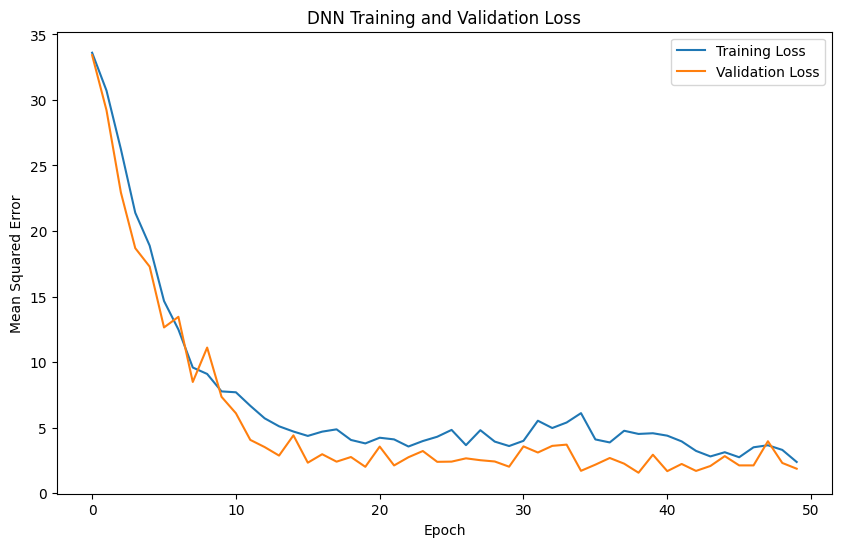

In [71]:
# Plot Training and Validation Loss for DNN
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

In [72]:

# Plot Confusion Matrices
def plot_confusion_matrix(y_true, y_pred, model_name, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

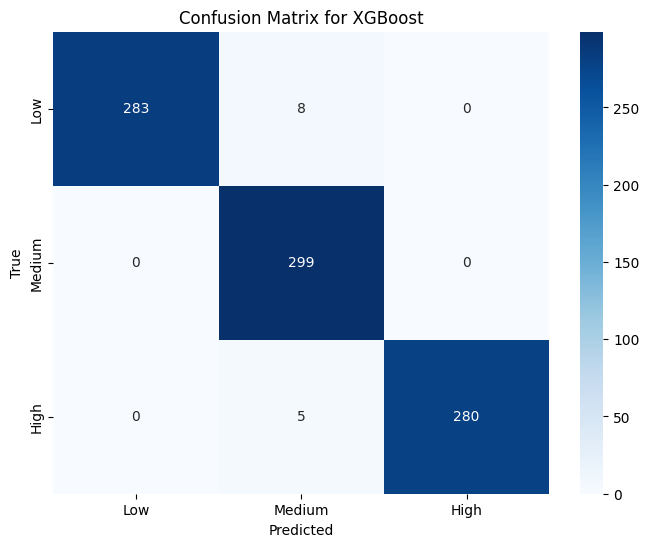

In [73]:
plot_confusion_matrix(y_test_discrete, xgb_pred_discrete, "XGBoost", class_labels)

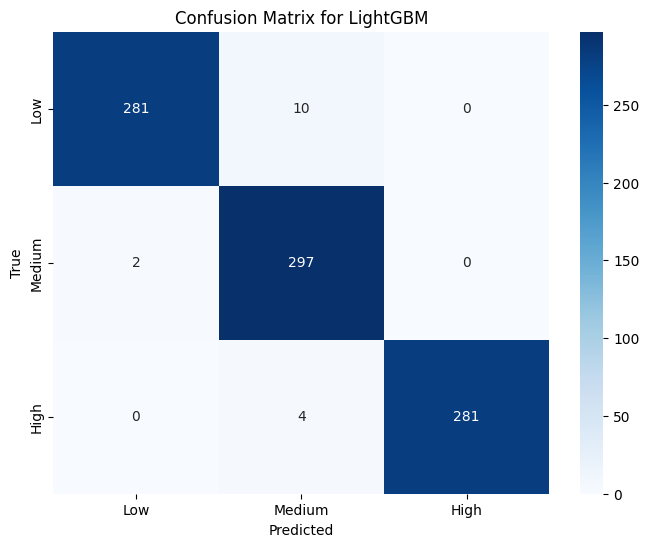

In [74]:
plot_confusion_matrix(y_test_discrete, lgb_pred_discrete, "LightGBM", class_labels)

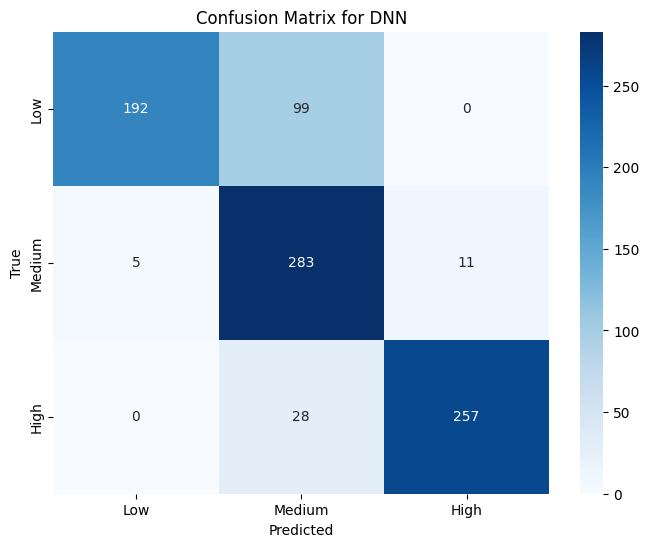

In [75]:
plot_confusion_matrix(y_test_discrete, dnn_pred_discrete, "DNN", class_labels)

## Visualizations
The following cells provide visualizations for data exploration, model evaluation, and feature importance.

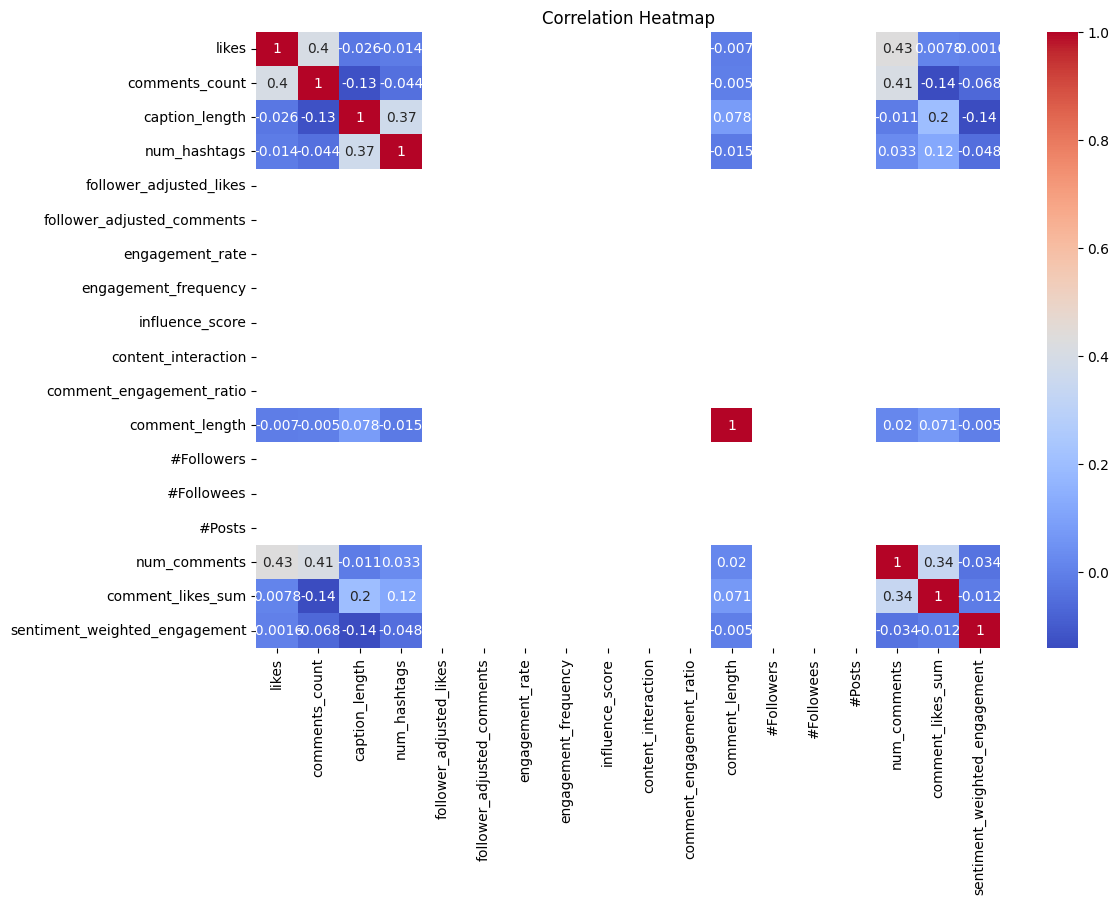

In [76]:
# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data[numerical_cols + ['sentiment_weighted_engagement']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

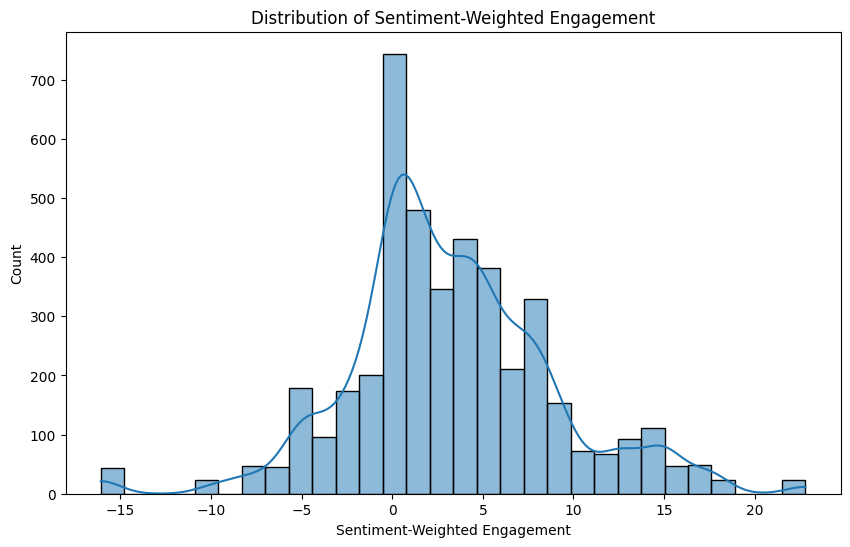

In [77]:
# 2. Engagement Distribution
plt.figure(figsize=(10, 6))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Sentiment-Weighted Engagement")
plt.xlabel("Sentiment-Weighted Engagement")
plt.show()

/tmp/ipython-input-78-4043274134.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_names, palette='viridis')


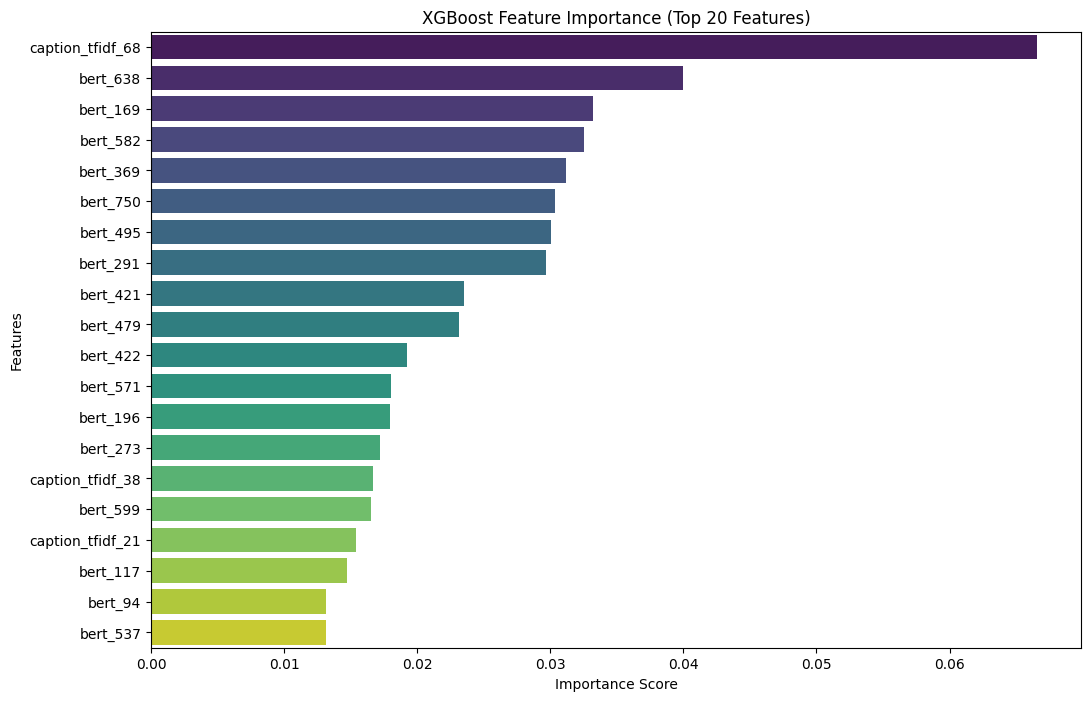

In [78]:
# 3. Feature Importance Plot for XGBoost
# Include all features (numerical, categorical, TF-IDF, BERT)
all_feature_names = (
    numerical_cols +
    categorical_cols +
    [f"caption_tfidf_{i}" for i in range(caption_tfidf.shape[1])] +
    [f"hashtag_tfidf_{i}" for i in range(hashtags_tfidf.shape[1])] +
    [f"bert_{i}" for i in range(bert_embeddings.shape[1])]
)
feature_importance = xgb_model.feature_importances_

# Select top 20 features for clarity
top_n = 20
if len(feature_importance) > top_n:
    indices = np.argsort(feature_importance)[::-1][:top_n]
    feature_importance = feature_importance[indices]
    feature_names = [all_feature_names[i] for i in indices]
else:
    feature_names = all_feature_names

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance, y=feature_names, palette='viridis')
plt.title("XGBoost Feature Importance (Top 20 Features)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

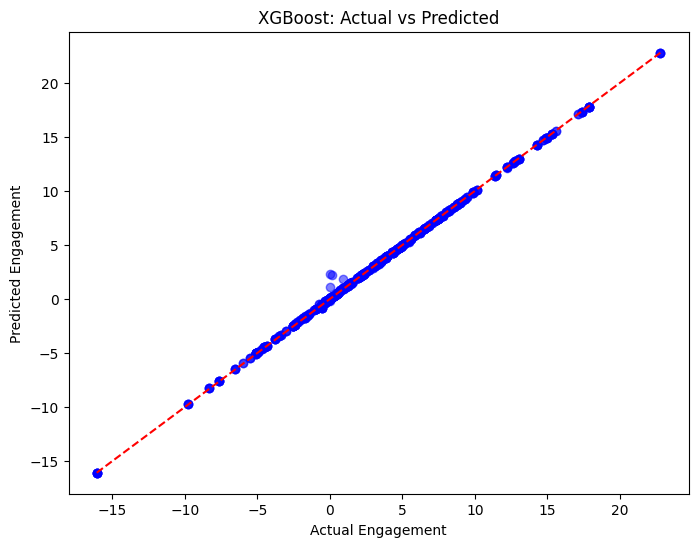

In [79]:
# 4. Actual vs Predicted Scatter Plots
# XGBoost
plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("XGBoost: Actual vs Predicted")
plt.show()


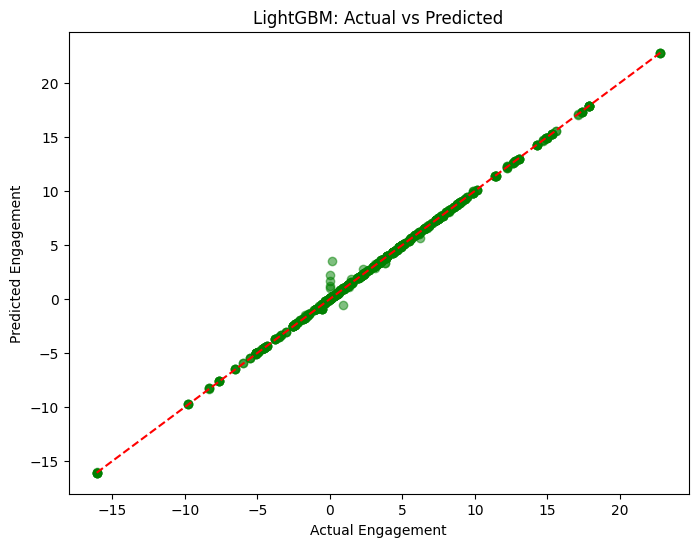

In [80]:

# LightGBM
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lgb_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("LightGBM: Actual vs Predicted")
plt.show()


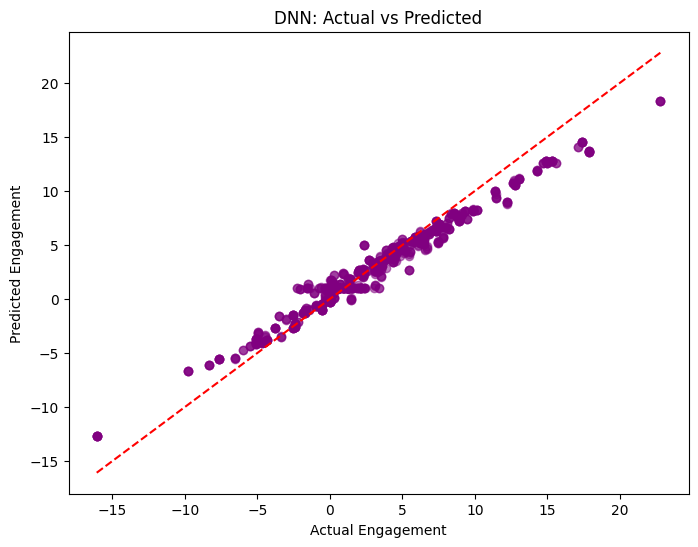

In [81]:

# DNN
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dnn_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("DNN: Actual vs Predicted")
plt.show()

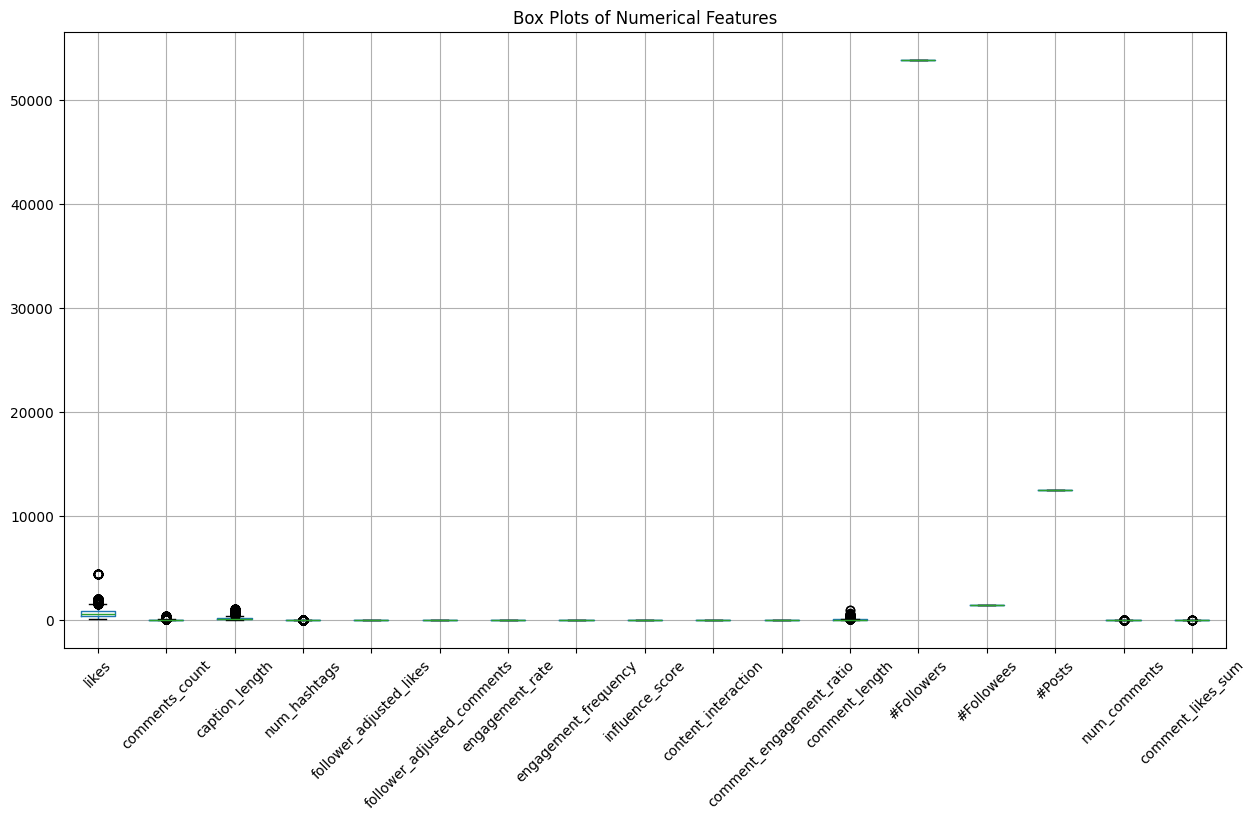

In [82]:
# 5. Box Plots for Numerical Features
plt.figure(figsize=(15, 8))
X[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Box Plots of Numerical Features")
plt.show()

/tmp/ipython-input-83-3256273481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_labels, y=media_engagement['sentiment_weighted_engagement'], palette='viridis')


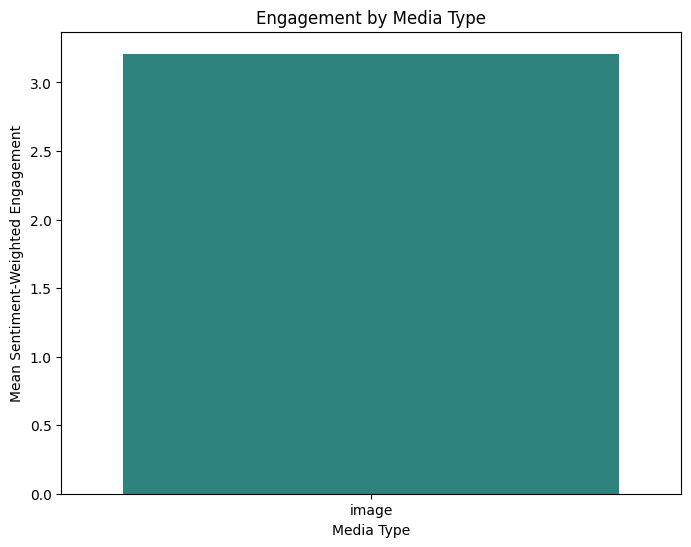

In [83]:

# 6. Bar Plot of Engagement by Categorical Features
# Media Type
media_engagement = X[['media_type']].join(y).groupby('media_type')['sentiment_weighted_engagement'].mean().reset_index()
media_labels = le_media_type.inverse_transform(media_engagement['media_type'].astype(int))
plt.figure(figsize=(8, 6))
sns.barplot(x=media_labels, y=media_engagement['sentiment_weighted_engagement'], palette='viridis')
plt.title("Engagement by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Mean Sentiment-Weighted Engagement")
plt.show()

/tmp/ipython-input-84-1743463162.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_means, y=['Beauty', 'Family', 'Fashion', 'Fitness', 'Food', 'Pet', 'Travel'], palette='viridis')


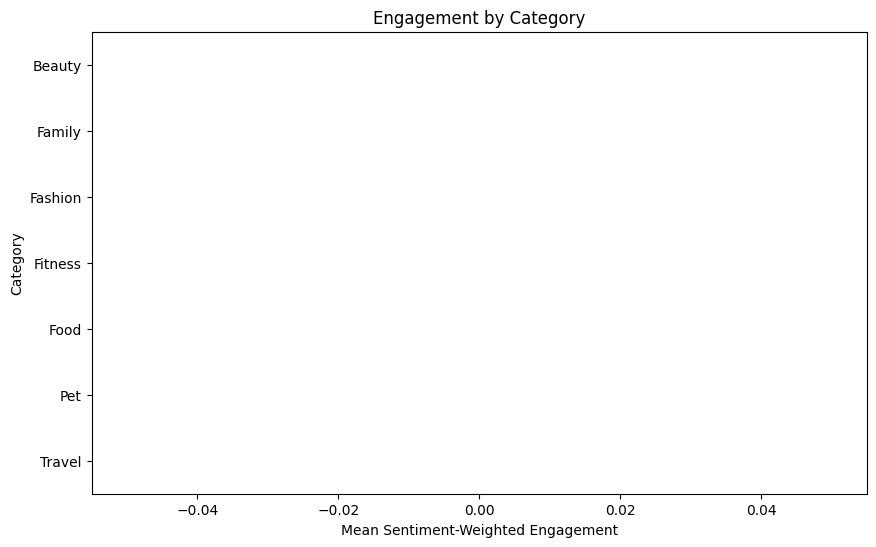

In [84]:

# Categories
category_cols = ['category_beauty', 'category_family', 'category_fashion', 'category_fitness',
                 'category_food', 'category_pet', 'category_travel']
category_means = [data[data[col] == 1]['sentiment_weighted_engagement'].mean() for col in category_cols]
category_means = [0 if pd.isna(x) else x for x in category_means]
plt.figure(figsize=(10, 6))
sns.barplot(x=category_means, y=['Beauty', 'Family', 'Fashion', 'Fitness', 'Food', 'Pet', 'Travel'], palette='viridis')
plt.title("Engagement by Category")
plt.xlabel("Mean Sentiment-Weighted Engagement")
plt.ylabel("Category")
plt.show()

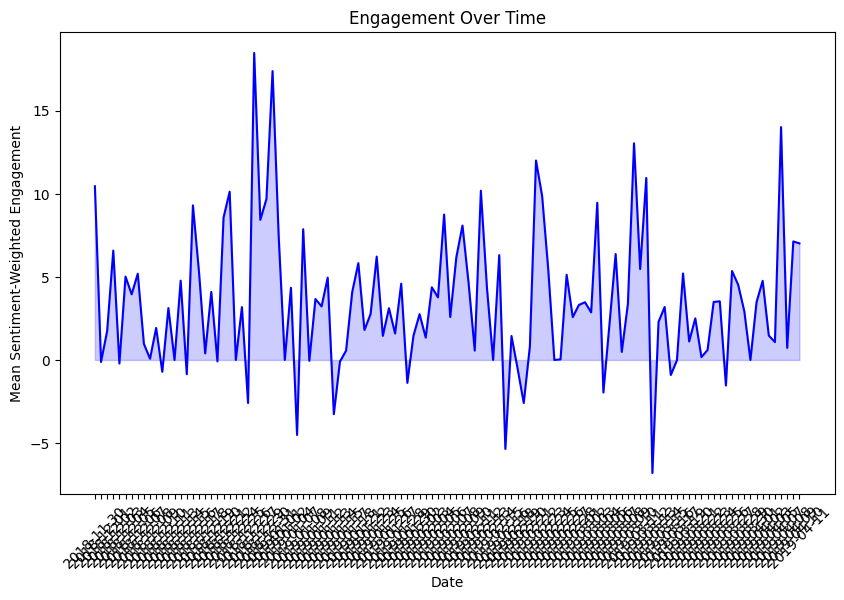

In [85]:
# 7. Time Series Plot
time_data = data.groupby(data['timestamp'].dt.date)['sentiment_weighted_engagement'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(time_data['timestamp'].astype(str), time_data['sentiment_weighted_engagement'], color='blue')
plt.fill_between(time_data['timestamp'].astype(str), time_data['sentiment_weighted_engagement'], alpha=0.2, color='blue')
plt.title("Engagement Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Sentiment-Weighted Engagement")
plt.xticks(rotation=45)
plt.show()

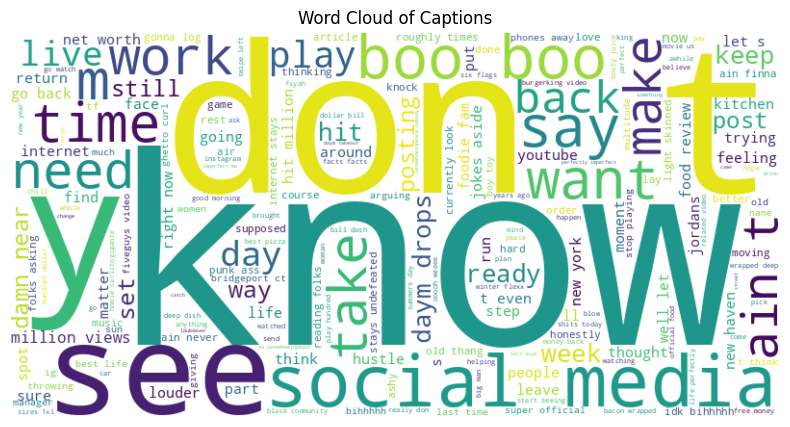

In [86]:
# 8. Word Cloud for Captions and Hashtags
caption_text = ' '.join(data['caption'].str.lower())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(caption_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Captions")
plt.show()


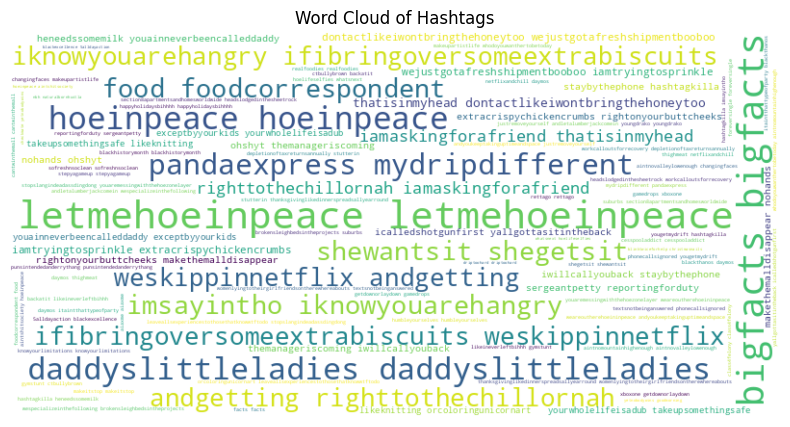

In [87]:
hashtag_text = ' '.join(data['hashtags'].str.lower())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(hashtag_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Hashtags")
plt.show()

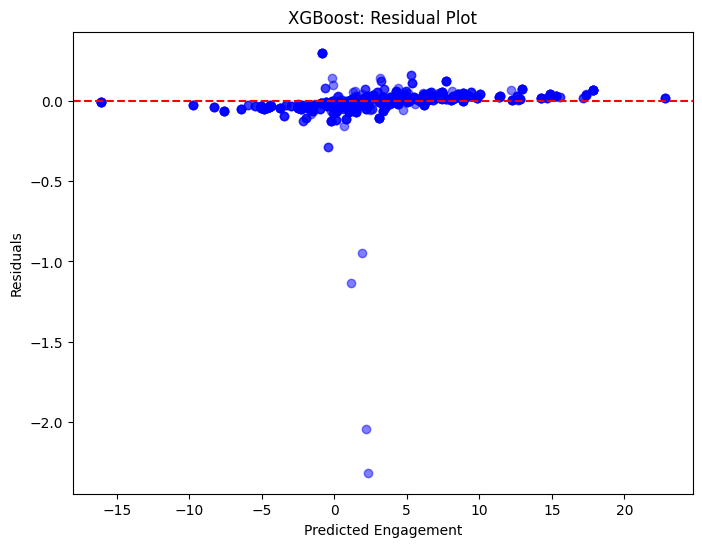

In [88]:
# 9. Residual Plots
# XGBoost
plt.figure(figsize=(8, 6))
plt.scatter(xgb_pred, y_test - xgb_pred, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Engagement")
plt.ylabel("Residuals")
plt.title("XGBoost: Residual Plot")
plt.show()


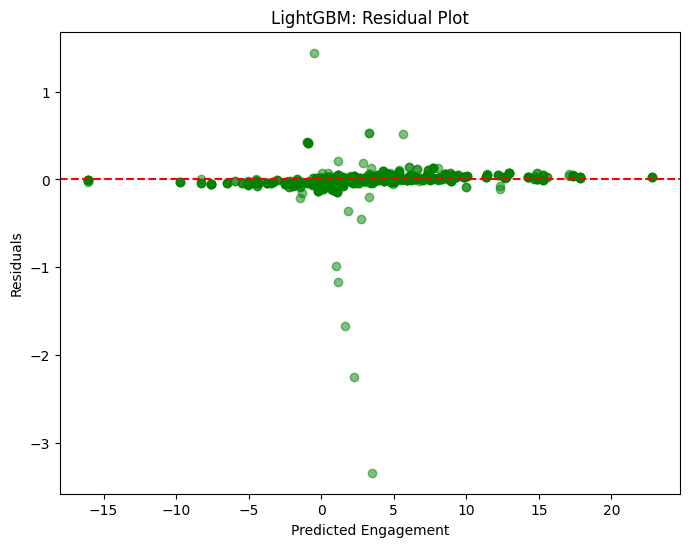

In [89]:

# LightGBM
plt.figure(figsize=(8, 6))
plt.scatter(lgb_pred, y_test - lgb_pred, alpha=0.5, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Engagement")
plt.ylabel("Residuals")
plt.title("LightGBM: Residual Plot")
plt.show()


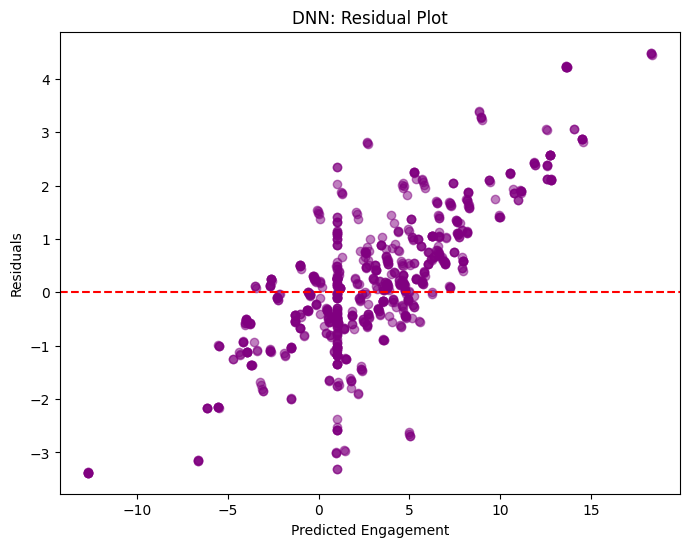

In [90]:

# DNN
plt.figure(figsize=(8, 6))
plt.scatter(dnn_pred, y_test - dnn_pred, alpha=0.5, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Engagement")
plt.ylabel("Residuals")
plt.title("DNN: Residual Plot")
plt.show()

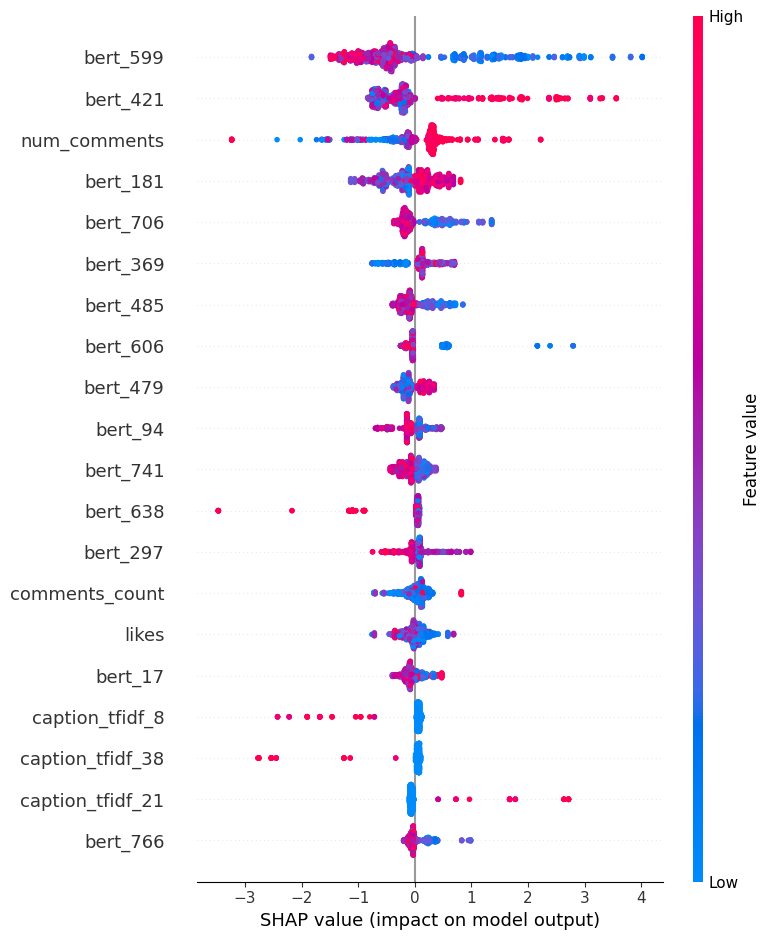

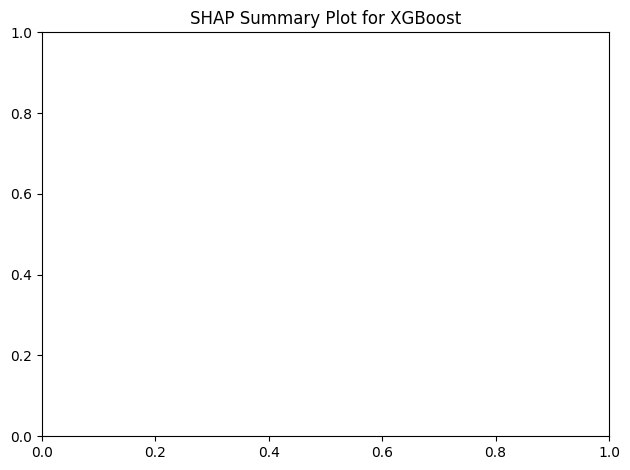

In [91]:
# 10. SHAP Summary Plot
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=(
    numerical_cols + categorical_cols +
    [f"caption_tfidf_{i}" for i in range(caption_tfidf.shape[1])] +
    [f"hashtag_tfidf_{i}" for i in range(hashtags_tfidf.shape[1])] +
    [f"bert_{i}" for i in range(bert_embeddings.shape[1])]
))
plt.title("SHAP Summary Plot for XGBoost")
plt.tight_layout()
plt.show()

In [92]:
# Keyword Recommendation System (Model-Based)
def recommend_keywords(caption, hashtags, numerical_features, categorical_features, model, top_n=5, max_candidates=100):
    """
    Recommend keywords and hashtags that maximize predicted sentiment weighted engagement using the XGBoost model.

    Parameters:
    - caption: Input caption (string)
    - hashtags: Input hashtags (string)
    - numerical_features: Numerical features for the input (array)
    - categorical_features: Categorical features for the input (array)
    - model: Trained XGBoost model
    - top_n: Number of keywords/hashtags to recommend
    - max_candidates: Maximum number of candidate words/hashtags to evaluate

    Returns:
    - caption_recommend: List of recommended caption keywords
    - hashtag_recommend: List of recommended hashtags
    """
    # Tokenize input
    caption_tokens = set(word_tokenize(caption.lower()))
    hashtag_tokens = set(word_tokenize(hashtags.lower()))

    # Get candidate keywords from TF-IDF vocabularies
    caption_vocab = list(tfidf_caption.vocabulary_.keys())
    hashtag_vocab = list(tfidf_hashtags.vocabulary_.keys())

    # Limit candidates to avoid excessive computation
    candidate_caption_words = [word for word in caption_vocab if word not in caption_tokens][:max_candidates]
    candidate_hashtags = [word for word in hashtag_vocab if word not in hashtag_tokens][:max_candidates]

    # Cache base features
    caption_tfidf_base = tfidf_caption.transform([caption]).toarray().astype(np.float32)
    hashtags_tfidf_base = tfidf_hashtags.transform([clean_hashtags(hashtags)]).toarray().astype(np.float32)
    inputs = tokenizer([caption], return_tensors='pt', max_length=128, padding=True, truncation=True)
    inputs = {key: val.to(device) for key, val in inputs.items()}
    with torch.no_grad():
        outputs = bert_model(**inputs)
    bert_base = outputs.pooler_output.cpu().numpy().astype(np.float32)
    numerical_scaled = scaler.transform([numerical_features]).astype(np.float32)
    categorical_features = np.array(categorical_features, dtype=np.float32).reshape(1, -1)

    # Evaluate caption keywords
    caption_scores = []
    for word in candidate_caption_words:
        modified_caption = caption + " " + word
        caption_tfidf_new = tfidf_caption.transform([modified_caption]).toarray().astype(np.float32)
        # Use cached BERT embedding (approximation, as single word addition has minimal impact)
        input_features = np.hstack([
            numerical_scaled,
            categorical_features,
            caption_tfidf_new,
            hashtags_tfidf_base,
            bert_base
        ]).astype(np.float32)
        score = model.predict(input_features)[0]
        caption_scores.append((word, score))

    # Evaluate hashtags
    hashtag_scores = []
    for hashtag in candidate_hashtags:
        modified_hashtags = hashtags + " #" + hashtag
        hashtags_tfidf_new = tfidf_hashtags.transform([clean_hashtags(modified_hashtags)]).toarray().astype(np.float32)
        input_features = np.hstack([
            numerical_scaled,
            categorical_features,
            caption_tfidf_base,
            hashtags_tfidf_new,
            bert_base
        ]).astype(np.float32)
        score = model.predict(input_features)[0]
        hashtag_scores.append((hashtag, score))

    # Sort by predicted engagement and select top_n
    caption_scores.sort(key=lambda x: x[1], reverse=True)
    hashtag_scores.sort(key=lambda x: x[1], reverse=True)

    caption_recommend = [word for word, _ in caption_scores[:top_n]]
    hashtag_recommend = [word for word, _ in hashtag_scores[:top_n]]

    return caption_recommend, hashtag_recommend

# Example recommendation
sample_caption = "In a World where folks rarely want to see you change, KEEP GETTIN' MONEY!"
sample_hashtags = "#bagsecured"
sample_numerical = X[numerical_cols].iloc[0].values
sample_categorical = X[categorical_cols].iloc[0].values
caption_rec, hashtag_rec = recommend_keywords(sample_caption, sample_hashtags, sample_numerical, sample_categorical, xgb_model)
print("Recommended Keywords for Caption:", caption_rec)
print("Recommended Hashtags:", hashtag_rec)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Recommended Keywords for Caption: ['drops', 'new', 'thang', 'love', 'hit']
Recommended Hashtags: ['2005', '1', 'food', 'foodcorrespondent', 'hoeinpeace']


In [93]:
# Predict Engagement for New Input
def predict_engagement(caption, hashtags, numerical_features, categorical_features):
    caption_tfidf_new = tfidf_caption.transform([caption]).toarray()
    hashtags_tfidf_new = tfidf_hashtags.transform([hashtags]).toarray()
    bert_new = get_bert_embeddings(pd.Series([caption]))

    numerical_scaled = scaler.transform([numerical_features])

    input_features = np.hstack([
        numerical_scaled,
        [categorical_features],
        caption_tfidf_new,
        hashtags_tfidf_new,
        bert_new
    ])

    pred = xgb_model.predict(input_features)[0]
    return pred

# Example prediction
sample_numerical = X[numerical_cols].iloc[0].values
sample_categorical = X[categorical_cols].iloc[0].values
pred_engagement = predict_engagement(sample_caption, sample_hashtags, sample_numerical, sample_categorical)
print(f"Predicted Sentiment-Weighted Engagement: {pred_engagement:.4f}")

Predicted Sentiment-Weighted Engagement: 3.6036


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Recommendations for High Engagement
- Use engaging captions with positive tone and clear calls-to-action.
- Include popular hashtags relevant to your category.
- Post during peak engagement times based on timestamp analysis.
- Leverage high-value followers by encouraging their interaction.